# Final Python Notebook 3

**Author:** Kalana Malhara

**Student Number:** w2120137 | 20240848

## Library Imports

**Code Reuse Session 3 - Seminnar Session 1,2,3 4, 7**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings


# Classification - ensemble
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier


# Regression
from sklearn.tree import DecisionTreeRegressor, plot_tree # Removed export_text

# Model selection and evaluation - classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    recall_score, precision_score, f1_score, roc_auc_score, RocCurveDisplay
)

# Model evaluation - regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Preprocessing
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

---
# Case Study A: Ensemble Classifier

## Task (5f) – Probability-Based Voting Ensemble Classifier

The ensemble combines **K-Nearest Neighbors (KNN)** and **Naive Bayes (NB)** as base learners.

**reason for choosing KNN + NB:**
- NB achieved high Recall, meaning it's good at identifying disapproved loans.
- KNN demonstrated strong overall performance with high precision for approved loans.


## Load the Classification Dataset

**Code Reuse Session 3 - Seminnar Session 1**

In [28]:
#Load the classification dataset
df_Classification = pd.read_csv('/content/drive/MyDrive/CW/classification_dataset.csv')

print("Shape:", df_Classification.shape)
df_Classification.head()

Shape: (58623, 11)


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0
1,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0
2,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0
3,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
4,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0


## Train - test spliting and feature scaling

**Code Reuse Session 3 - Seminnar Session 2**

In [29]:
#Input features
X = df_Classification.drop(columns=['loan_approval_status'])
#target variable
y = df_Classification['loan_approval_status']

#Same split parameters from the Notebook 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Same scaler as the Notebook 2
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #keep the test data unseen during the training process
X_test_scaled  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)


X_train shape: (46898, 10)
X_test shape:  (11725, 10)
y_train shape: (46898,)
y_test shape:  (11725,)


## Rebuild the Two Base Learners

**Code Reuse Session 3 - Seminnar Session 4**

In [30]:
# K-Nearest Neighbors with the tuned hyperparameters
knn_model = KNeighborsClassifier(n_neighbors=8, weights='distance', metric='manhattan')

# Fit the KNN model on the training data
knn_model.fit(X_train_scaled, y_train)

print("Base learner (KNN) rebuilt and fitted successfully.")

Base learner (KNN) rebuilt and fitted successfully.


**Code Reuse Session 3 - Seminnar Session 4**

In [31]:
# Naive Bayes model
nb_model = GaussianNB()

# Fit the model on the training data
nb_model.fit(X_train_scaled, y_train)

print("Naive Bayes model rebuilt and fitted successfully.")

Naive Bayes model rebuilt and fitted successfully.


## Naive Bayes Performance

**Code Reuse Session 3 - Seminnar Session 4**

In [36]:
#NB predictions
nb_pred = nb_model.predict(X_test_scaled)
#probability of disapproved class
nb_prob = nb_model.predict_proba(X_test_scaled)[:, 1]

#Classification report
print("Naive Bayes (NB) – Classification Report")
print(classification_report(y_test, nb_pred, target_names=['Approved (0)', 'Disapproved (1)']))

Naive Bayes (NB) – Classification Report
                 precision    recall  f1-score   support

   Approved (0)       0.93      0.88      0.91     10056
Disapproved (1)       0.46      0.60      0.52      1669

       accuracy                           0.84     11725
      macro avg       0.69      0.74      0.71     11725
   weighted avg       0.86      0.84      0.85     11725



**Code Reuse Session 3 - Seminnar Session 4**

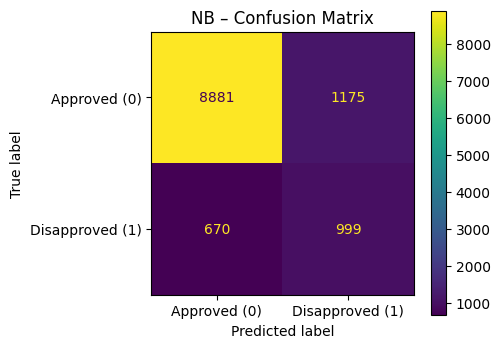

In [33]:
#Confusion matrix - NB
cm_nb = confusion_matrix(y_test, nb_pred)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Approved (0)', 'Disapproved (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_nb.plot(ax=ax)
ax.set_title('NB – Confusion Matrix')
plt.tight_layout()
plt.show()

**Code Reuse Session 3 - Seminnar Session 4**

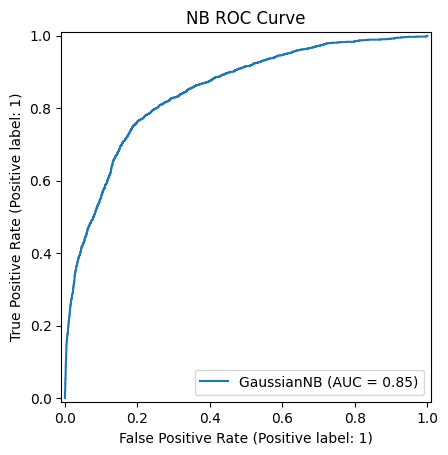

In [34]:
#AUC-ROC curve – NB
RocCurveDisplay.from_estimator(nb_model, X_test_scaled, y_test)
plt.title("NB ROC Curve")
plt.show()

## Base Learner Performances

### KNN Performance

**Code Reuse Session 3 - Seminnar Session 4**

In [35]:
#KNN predictions
knn_pred = knn_model.predict(X_test_scaled)
#probability of disapproved class
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

#Classification report
print("K-Nearest Neighbors (KNN) – Classification Report")
print(classification_report(y_test, knn_pred, target_names=['Approved (0)', 'Disapproved (1)']))

K-Nearest Neighbors (KNN) – Classification Report
                 precision    recall  f1-score   support

   Approved (0)       0.93      0.98      0.95     10056
Disapproved (1)       0.81      0.52      0.64      1669

       accuracy                           0.92     11725
      macro avg       0.87      0.75      0.79     11725
   weighted avg       0.91      0.92      0.91     11725



**Code Reuse Session 3 - Seminnar Session 4**

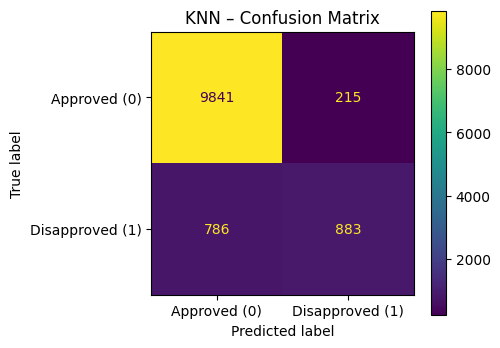

In [ ]:
#Confusion matrix - KNN
cm_knn = confusion_matrix(y_test, knn_pred) # Renamed to cm_knn
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Approved (0)', 'Disapproved (1)']) # Renamed to disp_knn
fig, ax = plt.subplots(figsize=(5, 4))
disp_knn.plot(ax=ax) # Removed cmap and colorbar arguments as per user preference
ax.set_title('KNN – Confusion Matrix')
plt.tight_layout()
plt.show()

**Code Reuse Session 3 - Seminnar Session 4**

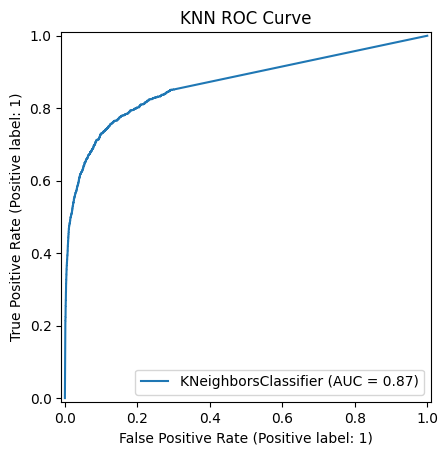

KNN: 0.8680


In [ ]:
#AUC-ROC curve – KNN

#Probability (kept for AUC print)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

#calculate AUC
knn_auc = roc_auc_score(y_test, knn_prob)

# Plot ROC curve using RocCurveDisplay
RocCurveDisplay.from_estimator(knn_model, X_test_scaled, y_test)
plt.title("KNN ROC Curve")
plt.show()

print(f"KNN: {knn_auc:.4f}")

## Build the Voting Ensemble Classifier

**Code Reuse Session 3 - Seminnar Session 7**

In [ ]:
# Create a dictionary of our TWO best learner models
base_learners = [('knn', knn_model), ('nb', nb_model)] # Using KNN and Naive Bayes

# Create our voting classifier, inputting our models with soft voting
ensemble_model = VotingClassifier(base_learners, voting='soft')

# Fit the super-model to the training data
ensemble_model.fit(X_train_scaled, y_train)

print("Ensemble (KNN + NB) fitted successfully")

Ensemble (KNN + NB) fitted successfully


**Code Reuse Session 3 - Seminnar Session 7**

In [ ]:
#predict labels using ensemble model
ensemble_pred = ensemble_model.predict(X_test_scaled)

#probability of dissaproved class
ensemble_prob = ensemble_model.predict_proba(X_test_scaled)[:, 1]

print("Voting Ensemble (KNN + NB) – Classification Report")
#Classification report
print(classification_report(
    y_test,
    ensemble_pred,
    target_names=['Approved (0)', 'Disapproved (1)']
))

Voting Ensemble (KNN + NB) – Classification Report
                 precision    recall  f1-score   support

   Approved (0)       0.93      0.95      0.94     10056
Disapproved (1)       0.65      0.59      0.62      1669

       accuracy                           0.90     11725
      macro avg       0.79      0.77      0.78     11725
   weighted avg       0.89      0.90      0.89     11725



**Code Reuse Session 3 - Seminnar Session 7**

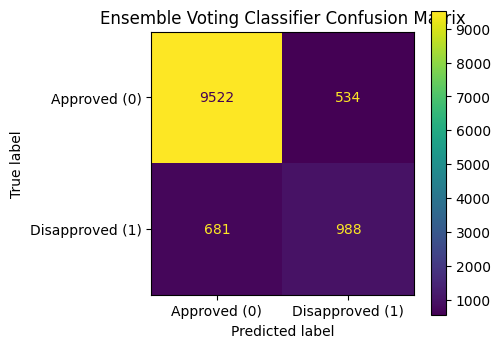

In [ ]:
#Confusion matrix - ensemble

cm_ensemble = confusion_matrix(y_test, ensemble_pred)
disp_ensemble = ConfusionMatrixDisplay(confusion_matrix=cm_ensemble, display_labels=['Approved (0)', 'Disapproved (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_ensemble.plot(ax=ax, )
ax.set_title('Ensemble Voting Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

**Code Reuse Session 3 - Seminnar Session 7**

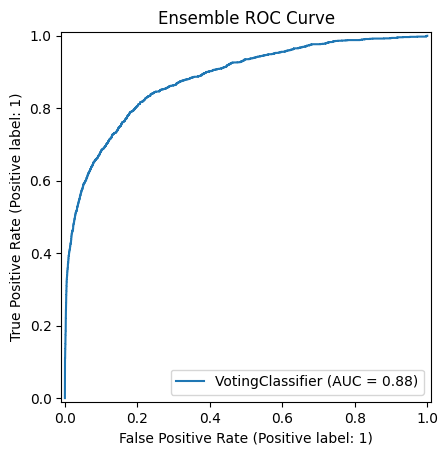

Ensemble AUC-ROC: 0.8821


In [ ]:
# Ensemble -  AUC-ROC
ensemble_auc = roc_auc_score(y_test, ensemble_prob)

# Use RocCurveDisplay.from_estimator for a cleaner plot
RocCurveDisplay.from_estimator(ensemble_model, X_test_scaled, y_test)
plt.title("Ensemble ROC Curve")
plt.show()

print(f"Ensemble AUC-ROC: {ensemble_auc:.4f}")

In [ ]:
#Compare all three models
comparison = pd.DataFrame({
    'Model':     ['KNN', 'NB', 'Ensemble (KNN+NB)'], # Updated models in comparison
    'Recall':    [
        round(recall_score (y_test, knn_pred, pos_label=1), 4),
        round(recall_score (y_test, nb_pred, pos_label=1), 4),
        round(recall_score (y_test, ensemble_pred, pos_label=1), 4),
    ],
    'Precision': [
        round(precision_score (y_test, knn_pred, pos_label=1), 4),
        round(precision_score (y_test, nb_pred, pos_label=1), 4),
        round(precision_score (y_test, ensemble_pred, pos_label=1), 4),
    ],
    'F-Score':   [
        round(f1_score (y_test, knn_pred, pos_label=1), 4),
        round(f1_score (y_test, nb_pred, pos_label=1), 4),
        round(f1_score (y_test, ensemble_pred, pos_label=1), 4),
    ],
    'AUC-ROC':   [
        round(knn_auc, 4), # Use the actual knn_auc for K-Nearest Neighbors
        round(nb_auc, 4),
        round(ensemble_auc, 4),
    ],
}).set_index('Model')

print("Ensemble vs Base Learners")
print("-" * 50)
print(comparison)

Ensemble vs Base Learners
--------------------------------------------------
                   Recall  Precision  F-Score  AUC-ROC
Model                                                 
KNN                0.5291     0.8042   0.6382   0.8680
NB                 0.5986     0.4595   0.5199   0.8476
Ensemble (KNN+NB)  0.5920     0.6491   0.6192   0.8821


---
# Case Study B: Predicting Maximum Loan Amount

## Task (1) – Regression Dataset


## Load the Regression Dataset

**Code Reuse Session 3 - Seminnar Session 1**

In [ ]:
#Load the regression dataset (from Notebook 1)
df_Regression = pd.read_csv('/content/drive/MyDrive/CW/regression_dataset.csv')

print("Regression Dataset")
print("Shape:", df_Regression.shape)
df_Regression.head()


Regression Dataset
Shape: (50274, 11)


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan
0,40.0,182004,3,3,1,35000,8.00,0.19,0,11,35000
1,40.0,90000,0,3,2,35000,12.42,0.39,0,14,35000
2,40.0,131004,0,9,5,30000,7.90,0.23,0,13,30000
3,40.0,150000,0,9,0,25000,11.89,0.17,0,11,25000
4,40.0,132000,0,3,2,25000,16.82,0.22,0,17,25000


**Code Reuse Session 3 - Seminnar Session 1**

In [ ]:
print("Feature names:")
print(df_Regression.columns)

Feature names:
Index(['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
       'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length', 'max_allowed_loan'],
      dtype='object')


## Task (2b) – Build the Two Regression Decision Tree Models

**Code Reuse Session 2 - Seminnar Session 2**

In [ ]:
#Separate input features and target variable
X_reg = df_Regression.drop(columns=['max_allowed_loan'])
y_reg = df_Regression['max_allowed_loan']

#Training-test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Regression training set shape:", X_reg_train.shape)
print("Regression test set shape:    ", X_reg_test.shape)
print("Regression target training set shape:", y_reg_train.shape)
print("Regression target test set shape:    ", y_reg_test.shape)


Regression training set shape: (40219, 10)
Regression test set shape:     (10055, 10)
Regression target training set shape: (40219,)
Regression target test set shape:     (10055,)


### DT-1: Full Decision Tree Regressor

**Code Reuse Session 3 - Seminnar Session 6**

In [ ]:
# declare Desicion Tree model
dt1_model = DecisionTreeRegressor(random_state=42)

#fit the training data
dt1_model.fit(X_reg_train, y_reg_train)

print("DT-1 (Fully Grown)")
print("Tree depth:", dt1_model.get_depth())
print("Number of leaves:", dt1_model.get_n_leaves())

DT-1 (Fully Grown)
Tree depth: 23
Number of leaves: 23029


### DT-2: Pruned Decision Tree Regressor (4 levels only)

**Code Reuse Session 3 - Seminnar Session 6**

In [ ]:
#Declare the prune DT model (used max_depth=4)
dt2_model = DecisionTreeRegressor(max_depth=4, random_state=42)

#fit the model to training data
dt2_model.fit(X_reg_train, y_reg_train)

print("DT-2 (Pruned, max_depth=4)")
print("Tree depth:", dt2_model.get_depth())
print("Number of leaves:", dt2_model.get_n_leaves())


DT-2 (Pruned, max_depth=4)
Tree depth: 4
Number of leaves: 16


## Task (2c) – Visualise DT-1 and DT-2

**Code Reuse Session 3 - Seminnar Session 6**

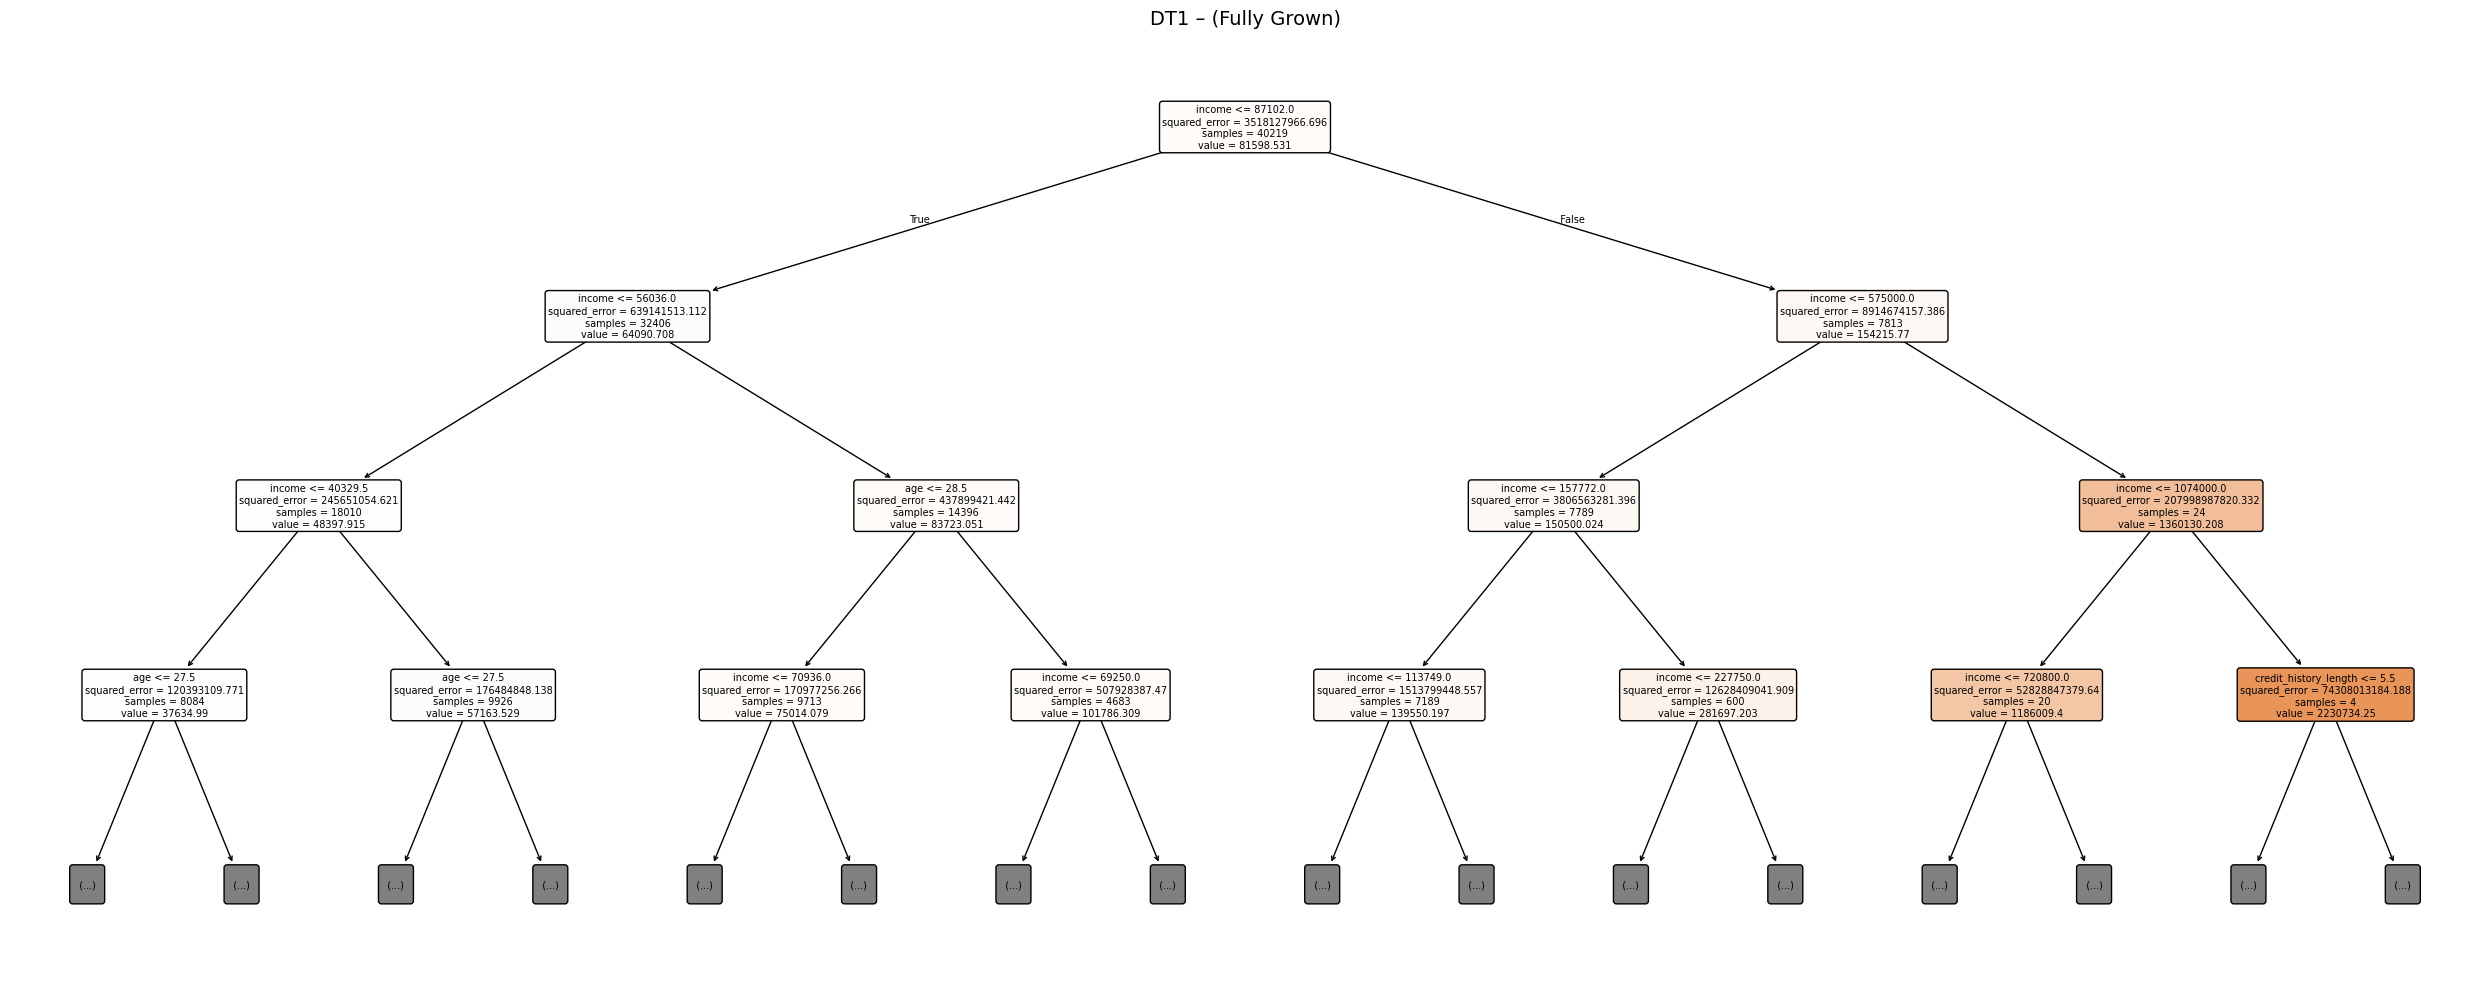

Full tree depth: 23 levels


In [ ]:
#Visualise DT-1 (fully grown )
plt.figure(figsize=(25, 10))
plot_tree(
    dt1_model,
    feature_names=X_reg.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=3 #used for better visibility.
)
plt.title('DT1 – (Fully Grown)', fontsize=14)
plt.tight_layout()
plt.show()

print("Full tree depth:", dt1_model.get_depth(), "levels")


**Code Reuse Session 3 - Seminnar Session 6**

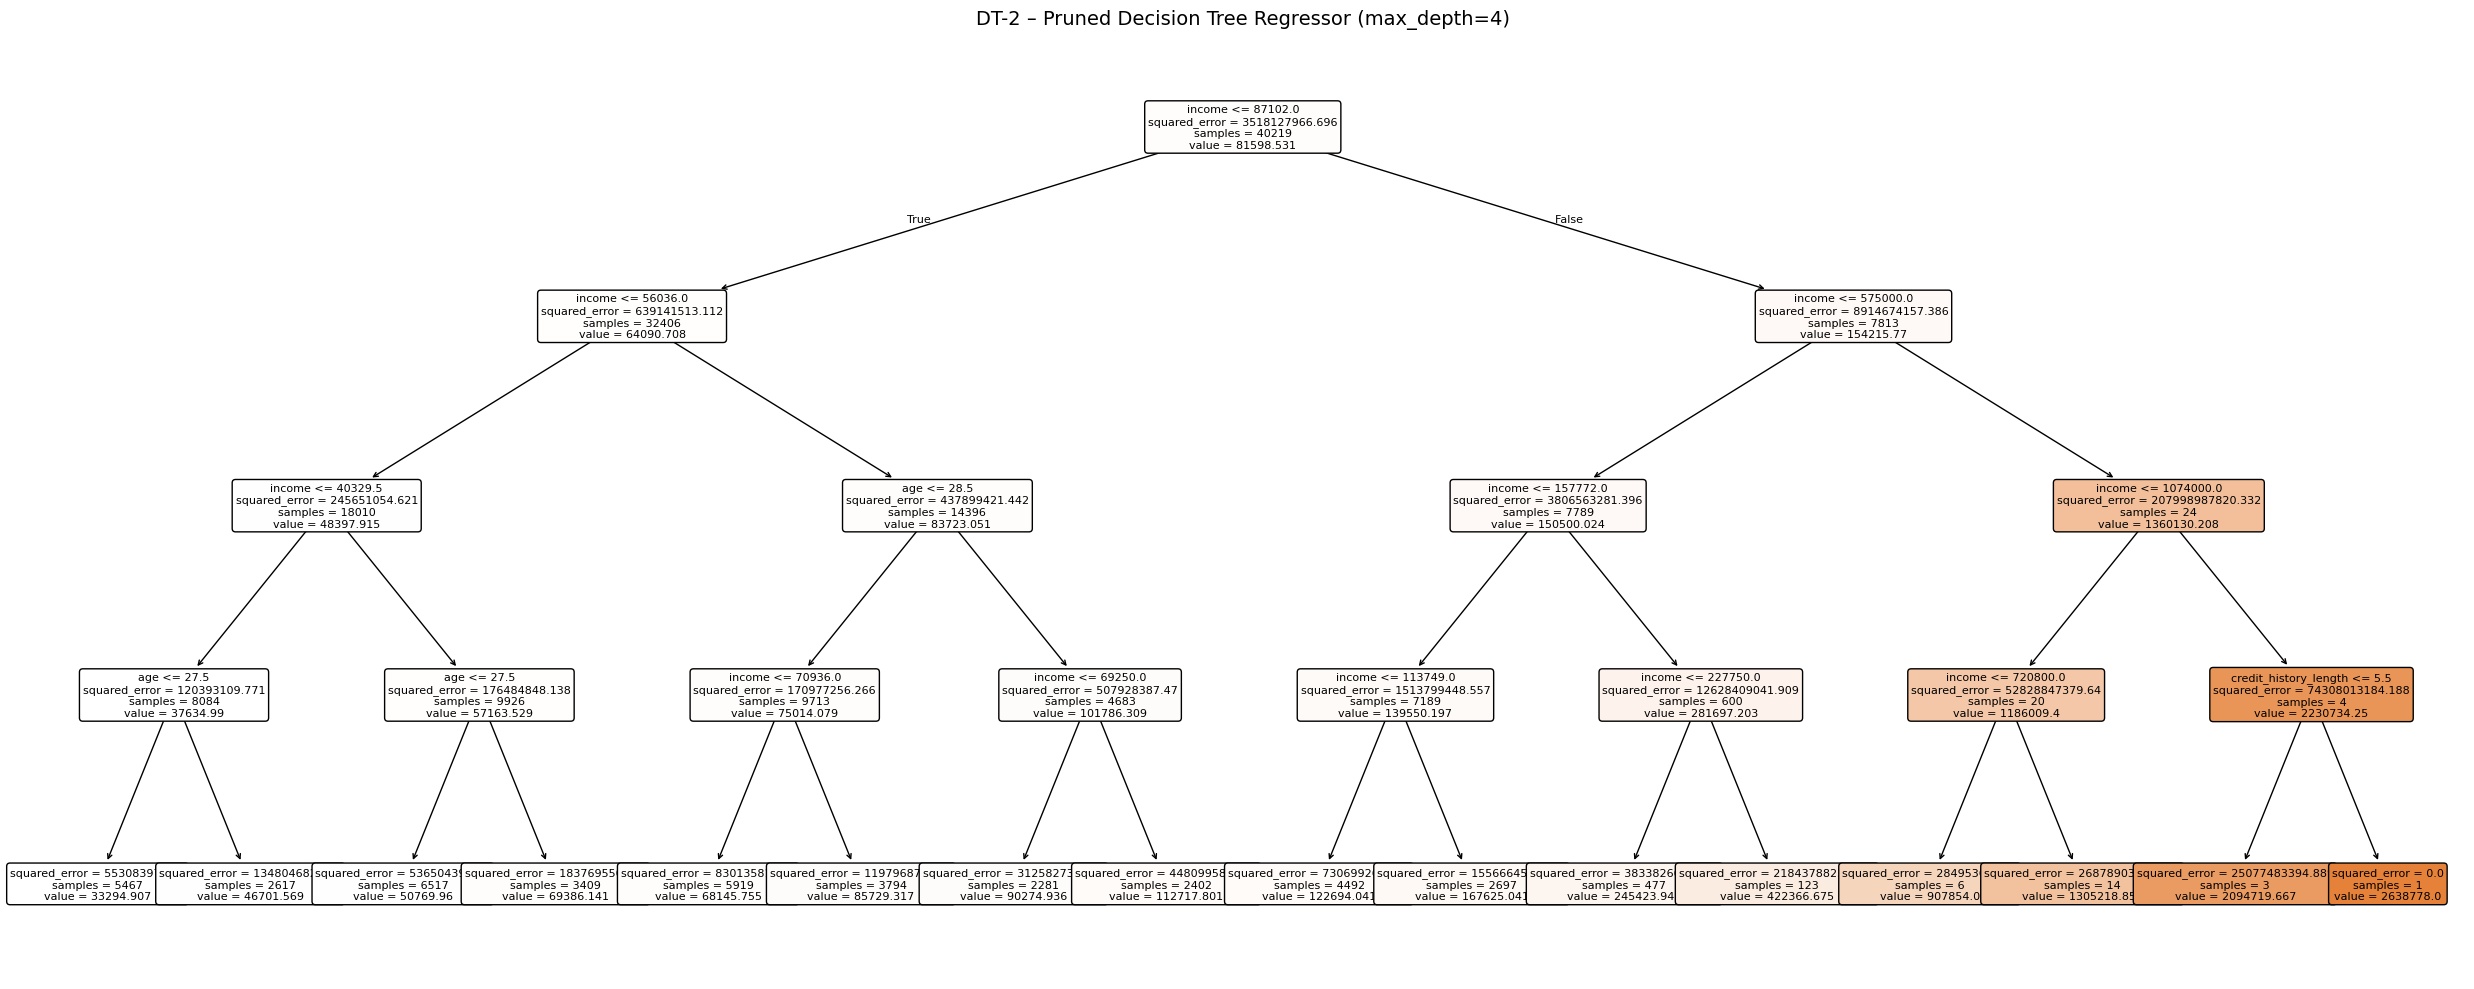

In [ ]:
#Visualise DT-2 (pruned to 4 levels)
plt.figure(figsize=(25, 10))
plot_tree(
    dt2_model,
    feature_names=X_reg.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('DT-2 – Pruned Decision Tree Regressor (max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()


**Code Reuse Session 3 - Seminnar Session 6**

In [ ]:
# Predict on the test set for both models
dt1_pred = dt1_model.predict(X_reg_test)
dt2_pred = dt2_model.predict(X_reg_test)

# Calculate regression metrics with readable formatting
metrics_reg = pd.DataFrame({
    'Model': ['DT1 (Fully Grown)', 'DT2 (Pruned, max_depth=4)'],
    'MSE': [
        mean_squared_error(y_reg_test, dt1_pred),
        mean_squared_error(y_reg_test, dt2_pred),
    ],
    'MAE': [
        round(mean_absolute_error(y_reg_test, dt1_pred), 2),
        round(mean_absolute_error(y_reg_test, dt2_pred), 2),
    ],
    'R-Square': [
        round(r2_score(y_reg_test, dt1_pred), 4),
        round(r2_score(y_reg_test, dt2_pred), 4),
    ],
}).set_index('Model')

#Since MSE was a large values used a map to 2 decimal places
metrics_reg['MSE'] = metrics_reg['MSE'].map('{:.2f}'.format)

print("Regression Model Evaluation")
print("-" * 50)
print(metrics_reg)

Regression Model Evaluation
--------------------------------------------------
                                    MSE       MAE  R-Square
Model                                                      
DT1 (Fully Grown)          132719134.34   1316.99    0.9529
DT2 (Pruned, max_depth=4)  432985641.59  11646.71    0.8464


Based on the evaluation result the DT1 model was choosen as the best model
- DT1 has much lower MSE compareto DT2, which means it prediction are closer to actual values

- DT1 has smaller MAE , which means it makes far smaller mistakes

- DT1 has 95% accuracy

## Task (3d) – Predict Maximum Loan Amount for Client 60256

In [ ]:
#Client 60256
# Updating client_60256 to use integer-encoded features as per the training data for dt1_model.
# Home Ownership Encoded Values: MORTGAGE: 0, OTHER: 1, OWN: 2, RENT: 3
# Loan Intent Encoded Values: DEBTCONSOLIDATION: 0, EDUCATION: 1, HOMEIMPROVEMENT: 2, MEDICAL: 3, PERSONAL: 4, VENTURE: 5
client_60256 = pd.DataFrame([{
    'age':                         56,
    'income':                      57000,
    'home_ownership':              3,
    'emplyment_length':            15,
    'loan_intent':                 3,
    'loan_amount':                 25700,
    'loan_interest_rate':          23.0,
    'loan_income_ratio':           0.10,
    'payment_default_on_file':     0,
    'credit_history_length':       35,
}])

print("Client 60256 feature vector:")
print(client_60256.to_string())

Client 60256 feature vector:
   age  income  home_ownership  emplyment_length  loan_intent  loan_amount  loan_interest_rate  loan_income_ratio  payment_default_on_file  credit_history_length
0   56   57000               3                15            3        25700                23.0                0.1                        0                     35


**Code Reuse Session 3 - Seminnar Session 6**

In [ ]:
#Predict using DT-1 (since it was the best model)
prediction_dt1 = dt1_model.predict(client_60256)[0]
print(f"Maximum Loan Amount for Client 60256: £ {prediction_dt1:.2f}")

#Show the decision path

#which nodes were used to make the prediciton
decision_path = dt1_model.decision_path(client_60256)
#covert the matrix to an array
node_indicator = decision_path.toarray()[0]
#get the ids of the nodes that actucally visited
node_ids = np.where(node_indicator)[0]

#how many nodes were visited
print(f"\nDecision path ({len(node_ids)} nodes visited):")


Maximum Loan Amount for Client 60256: £ 93997.00

Decision path (15 nodes visited):
